In [1]:
import sys
from pathlib import Path

root_dir = Path().absolute()
# Strip ~/notebooks/ccfraud from PYTHON_PATH if notebook started in one of these subdirectories
if root_dir.parts[-1:] == ('notebooks',):
    root_dir = Path(*root_dir.parts[:-1])
    sys.path.append(str(root_dir))
if root_dir.parts[-1:] == ('titanic',):
    root_dir = Path(*root_dir.parts[:-1])
    sys.path.append(str(root_dir))
root_dir = str(root_dir) 

print(f"Root dir: {root_dir}")

# Set the environment variables from the file <root_dir>/.env
from mlfs import config
settings = config.HopsworksSettings(_env_file=f"{root_dir}/.env")

Root dir: /Users/igormedeiros/Workspaces/irgmedeiros/mlfs-book
HopsworksSettings initialized!


In [2]:
from PIL import Image
import datetime
import requests
import xgboost as xgb
import os
import hopsworks
import pandas as pd
import datetime
import joblib

In [3]:
project = hopsworks.login()
fs = project.get_feature_store()

2026-07-07 22:09:27,018 INFO: Initializing external client


2026-07-07 22:09:27,018 INFO: Base URL: https://eu-west.cloud.hopsworks.ai:443


2026-07-07 22:09:30,302 INFO: Python Engine initialized.



Logged in to project, explore it here https://eu-west.cloud.hopsworks.ai:443/p/36986


In [4]:
mr = project.get_model_registry()
model_reg = mr.get_model("titanic", version=1)
feature_view = model_reg.get_feature_view()

# Downloads the model to a local temp directory (model_dir)
model_dir = model_reg.download()
# Load XGBoost model from local temp directory using joblib
model = joblib.load(model_dir + "/titanic_model.pkl")

2026-07-07 22:09:37,916 INFO: Initializing for batch retrieval of feature vectors


Using cached model files at '/tmp/hopsworks/models/featurestorebook/titanic/1/titanic_1'. Pass local_path or call Model.clear_cache(...) to force a fresh download.


In [5]:
training_dataset_version = max(td.version for td in feature_view.get_training_datasets())
feature_view.init_batch_scoring(training_dataset_version=training_dataset_version)

batch_data = feature_view.get_batch_data()
batch_data

Finished: Reading data from Hopsworks, using Hopsworks Feature Query Service (1.79s) 


,age,pclass,fare,parch,sibsp,label_encoder_embarked_,label_encoder_sex_
0,70.254635,3,51.84791,1,1,0,1
1,22.000000,3,7.25000,0,1,2,1
2,38.000000,1,71.28330,0,1,0,0
3,26.000000,3,7.92500,0,0,2,0
4,35.000000,1,53.10000,0,1,2,0
...,...,...,...,...,...,...,...
887,27.000000,2,13.00000,0,0,2,1
888,19.000000,1,30.00000,0,0,2,0
889,29.699118,3,23.45000,2,1,2,0
890,26.000000,1,30.00000,0,0,0,1


In [6]:
y_pred = model.predict(batch_data)
passenger_survived = y_pred[y_pred.size-1]
passenger_survived

np.int64(0)

In [7]:
passenger_details = batch_data.iloc[-1]
def remove_last_line_from_string(s):
    return s[:s.rfind('\n')]
passenger_details = remove_last_line_from_string(str(passenger_details))

with open(f"{root_dir}/docs/_includes/titanic.html", "w", newline="\n") as file:
    file.write(passenger_details)

In [8]:
img_url = "https://raw.githubusercontent.com/featurestorebook/mlfs-book/main/docs/titanic/assets/img/titanic_" + str(passenger_survived) + ".jpg"
img = Image.open(requests.get(img_url, stream=True).raw)            
output_img_path = f"{root_dir}/docs/titanic/assets/img/latest_titanic_survival.jpg"
img.save(output_img_path)

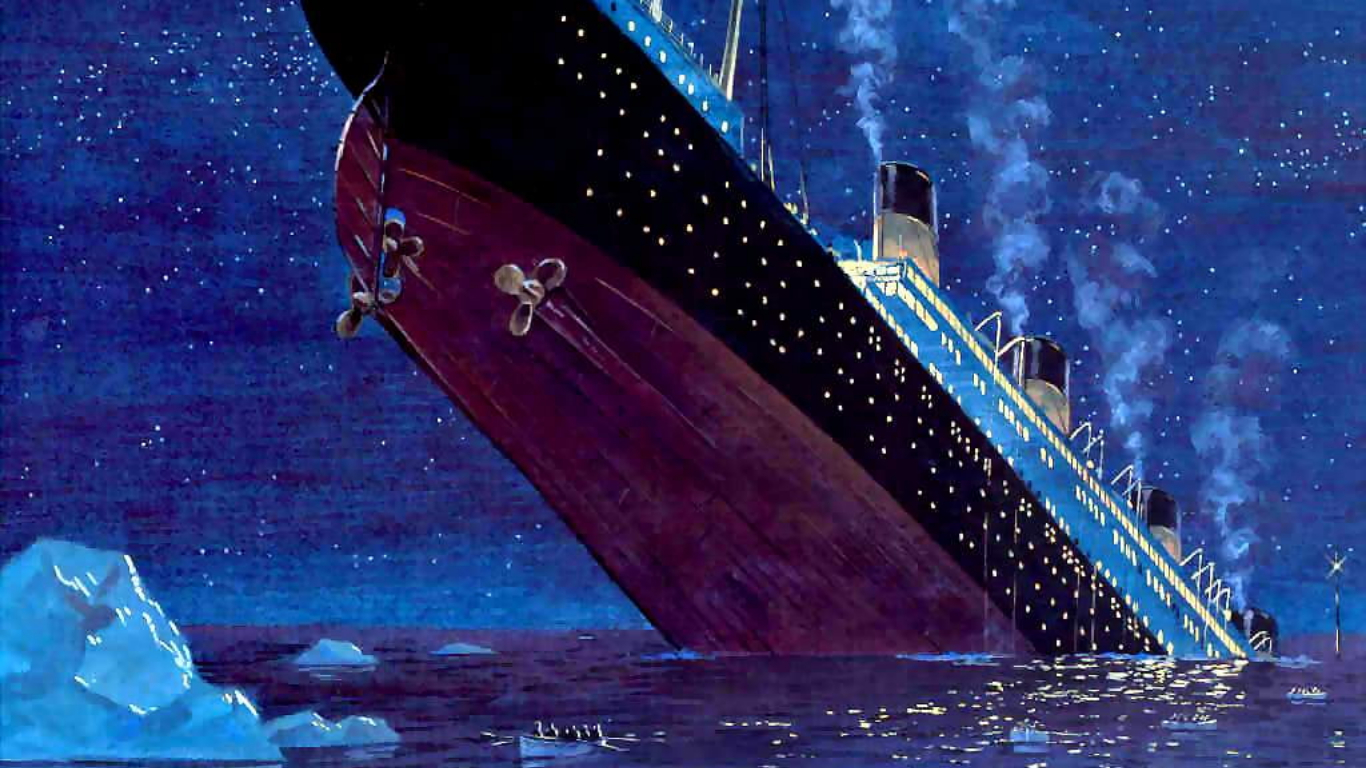

In [9]:
from IPython.display import display
display(img)

In [10]:
today = datetime.datetime.now() - datetime.timedelta(0)
dataset_api = project.get_dataset_api()
str_today = today.strftime("%Y-%m-%d")
if dataset_api.exists("Resources/titanic") == False:
    dataset_api.mkdir("Resources/titanic")
dataset_api.upload(output_img_path, f"Resources/titanic/{str_today}", overwrite=True)
proj_url = project.get_url()
print(f"See images in Hopsworks here: {proj_url}/settings/fb/path/Resources/titanic")

Uploading /Users/igormedeiros/Workspaces/irgmedeiros/mlfs-book/docs/titanic/assets/img/latest_titanic_survival.jpg: 0.000%|          | 0/134023 elapsed<00:00 remaining<?

Uploading /Users/igormedeiros/Workspaces/irgmedeiros/mlfs-book/docs/titanic/assets/img/latest_titanic_survival.jpg: 100.000%|██████████| 134023/134023 elapsed<00:08 remaining<00:00

Uploading /Users/igormedeiros/Workspaces/irgmedeiros/mlfs-book/docs/titanic/assets/img/latest_titanic_survival.jpg: 100.000%|██████████| 134023/134023 elapsed<00:08 remaining<00:00

See images in Hopsworks here: https://eu-west.cloud.hopsworks.ai:443/p/36986/settings/fb/path/Resources/titanic
